In [1]:
%load_ext autoreload
import os
import sys
from pathlib import Path

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.pipeline.data_loader import DataLoader
from src.pipeline.seasonality_etl import SeasonalityETL

### Load data

In [3]:
# add 'src' to sys.path if needed (adjust path as necessary)
sys.path.insert(0, str(Path("src").resolve()))

# 1: load data
loader = DataLoader(
    config_path="../config/tickers_list.yaml",
    use_cache=False,
    verbose=True,
)
df = loader.load(start_date="2022-01-01", intervals=["1d"])
print(f"Loaded data: {df.shape}")

# 2: compute rolling metrics
etl = SeasonalityETL()
df_rolling = etl.fit_rolling(df, frequencies=["W", "ME", "QE", "YE"])

print(f"Computed rolling metrics: {df_rolling.shape}")

INFO:src.pipeline.data_loader:Saved combined data to data/.cache/all_data_20250731.parquet


Loaded data: (28359, 8)


/Users/danielsflamarich/Documents/stock-seasonality/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Computed rolling metrics: (6415, 10)


### Basic checks

In [4]:
print(f'Number of rows and columns: {df_rolling.shape[0], df_rolling.shape[1]}')

Number of rows and columns: (6415, 10)


In [5]:
df_rolling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6415 entries, 0 to 6414
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ticker                      6415 non-null   object        
 1   interval                    6415 non-null   object        
 2   freq                        6415 non-null   object        
 3   window_start                6415 non-null   datetime64[ns]
 4   acf_lag_val                 6415 non-null   float64       
 5   p2m_val                     6415 non-null   float64       
 6   stl_strength                6415 non-null   float64       
 7   seasonality_score_linear    6415 non-null   float64       
 8   seasonality_score_geom      6415 non-null   float64       
 9   seasonality_score_harmonic  6415 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(3)
memory usage: 501.3+ KB


In [6]:
print(f"data starts: {df_rolling.groupby('freq').window_start.min()}")
print(f"data ends: end_date = {df_rolling.groupby('freq').window_start.max()}")

data starts: freq
ME   2022-01-31
QE   2022-03-31
W    2022-01-09
YE   2022-12-31
Name: window_start, dtype: datetime64[ns]
data ends: end_date = freq
ME   2025-07-31
QE   2025-09-30
W    2025-08-03
YE   2025-12-31
Name: window_start, dtype: datetime64[ns]


### Prepare both datasets

In [9]:
df["date"] = pd.to_datetime(df["date"])

# aggregation rules for OHLCV
agg_rules = {
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}

# mapping of ETL frequencies to Pandas resample rules
freq_map = {
    "W": "W-SUN",   
    "ME": "ME",            
}

In [10]:
resampled_list = []

for freq, rule in freq_map.items():
    df_resampled = (
        df.groupby("ticker")
          .resample(rule, on="date")
          .agg(agg_rules)
          .reset_index()
    )
    df_resampled["freq"] = freq
    df_resampled.rename(columns={"date": "window_start"}, inplace=True)
    resampled_list.append(df_resampled)

# combine weekly and monthly resampled data
df_resampled = pd.concat(resampled_list, ignore_index=True)

# merge with rolling metrics
df_model = pd.merge(
    df_rolling,
    df_resampled,
    on=["ticker", "freq", "window_start"],
    how="inner"
)

print(df_model.shape)
df_model.head()

(5838, 15)


,ticker,interval,freq,window_start,acf_lag_val,p2m_val,stl_strength,seasonality_score_linear,seasonality_score_geom,seasonality_score_harmonic,open,high,low,close,volume
0,7974.T,1d,ME,2022-01-31,0.801162,0.248174,0.0,0.349779,0.0,0.000003,4902.396673,5184.738545,4670.895437,5098.492676,135805000
1,7974.T,1d,ME,2022-02-28,0.499814,0.060474,0.0,0.186763,0.0,0.000003,5188.370617,5410.793629,5078.520084,5267.352539,136091000
2,7974.T,1d,ME,2022-03-31,0.954169,0.418372,0.0,0.457514,0.0,0.000003,5344.520487,6089.866462,5074.888551,5719.094238,157655000
3,7974.T,1d,ME,2022-04-30,0.758269,0.216112,0.0,0.324794,0.0,0.000003,5817.395168,6087.260340,5532.692203,5555.876465,110314000
4,7974.T,1d,ME,2022-05-31,0.628708,0.081259,0.0,0.236656,0.0,0.000003,5490.033614,5587.407330,5130.213624,5324.960938,148246000


## EDA

In [13]:
df_w = df_model[df_model["freq"] == "W"].copy()
df_m = df_model[df_model["freq"] == "ME"].copy()

features = [
    "ticker",
    "window_start", 
    "open", 
    "high", 
    "low", 
    "close", 
    "volume", 
    "acf_lag_val", 
    "p2m_val"
]

df_w = df_w[features].dropna()
df_m = df_m[features].dropna()

In [14]:
for name, df_freq in {"Weekly": df_w, "Monthly": df_m}.items():
    print(f"\n{name} Data:")
    print(df_freq.describe())
    print(df_freq["ticker"].value_counts().head())


Weekly Data:
                        window_start          open          high  \
count                           4544   4544.000000   4544.000000   
mean   2023-10-25 06:00:38.028168704    495.893142    525.191544   
min              2022-01-09 00:00:00      0.190000      0.380000   
25%              2022-12-04 00:00:00      7.127500      7.950000   
50%              2023-10-29 00:00:00     47.213123     48.645993   
75%              2024-09-15 00:00:00    149.812296    157.714996   
max              2025-08-03 00:00:00  27300.000000  28620.000000   
std                              NaN   2045.831510   2187.074428   

                low         close        volume  acf_lag_val      p2m_val  
count   4544.000000   4544.000000  4.544000e+03  4544.000000  4544.000000  
mean     463.709051    490.823701  1.201526e+08     0.596254     0.227708  
min        0.170000      0.300000  0.000000e+00     0.000000     0.000000  
25%        6.555000      7.110000  9.961000e+05     0.473818     0.11

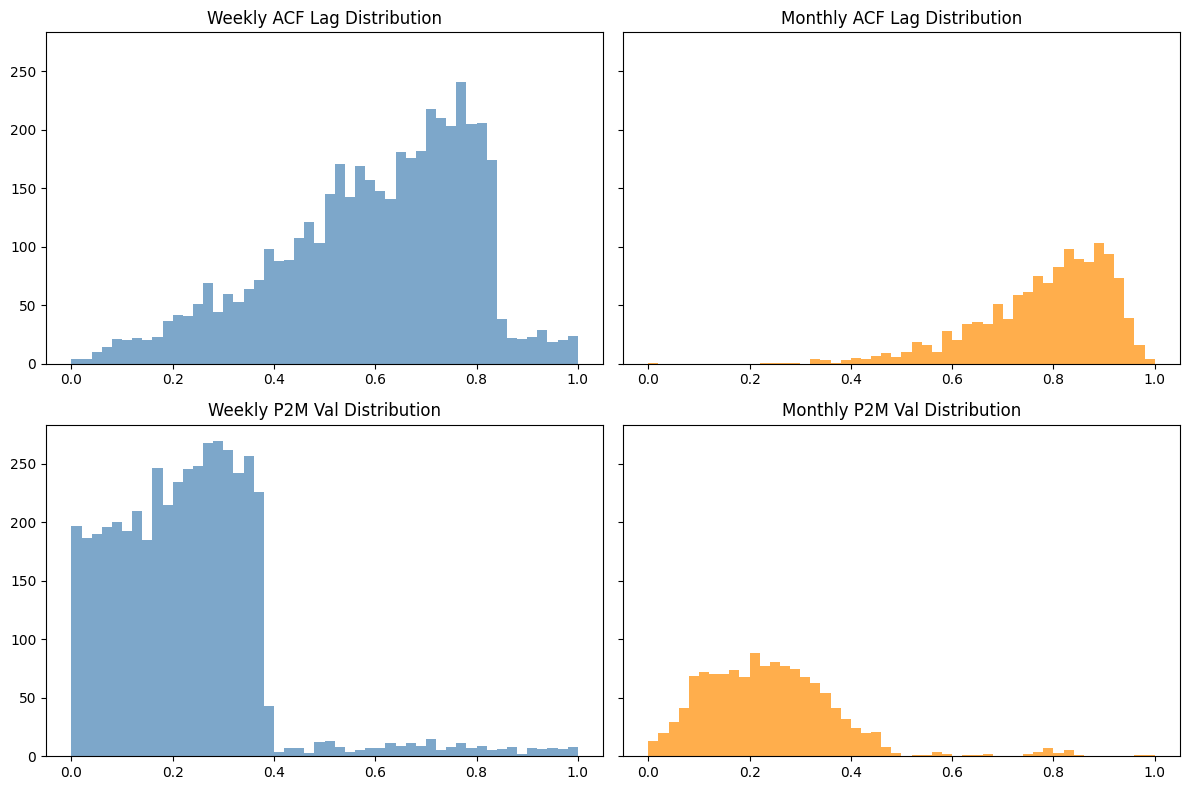

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

axes[0, 0].hist(df_w["acf_lag_val"], bins=50, alpha=0.7, color="steelblue")
axes[0, 0].set_title("Weekly ACF Lag Distribution")

axes[0, 1].hist(df_m["acf_lag_val"], bins=50, alpha=0.7, color="darkorange")
axes[0, 1].set_title("Monthly ACF Lag Distribution")

axes[1, 0].hist(df_w["p2m_val"], bins=50, alpha=0.7, color="steelblue")
axes[1, 0].set_title("Weekly P2M Val Distribution")

axes[1, 1].hist(df_m["p2m_val"], bins=50, alpha=0.7, color="darkorange")
axes[1, 1].set_title("Monthly P2M Val Distribution")

plt.tight_layout()
plt.show()

**ACF**
- Weekly (W):
    - Distribution is spread across 0.2–0.9, with a peak around 0.7–0.8.
    - This suggests moderate to strong autocorrelation is common, but there is also a significant fraction of low values (weak seasonality).
    - Indicates heterogeneity across tickers/windows — some weeks exhibit clear patterns, others not.

- Monthly (ME):
    - Distribution is skewed toward high values (0.7–1.0).
    - Fewer low values compared to weekly.
    - This suggests seasonality is stronger at the monthly scale, aligning with the idea that monthly patterns are more stable and less noisy.

**P2M**
- Weekly (W):
    - Bimodal-like behavior: many values cluster near 0–0.4, and then a long tail with sparse high values.
    - Indicates that the P2M metric often signals no seasonality (low values dominate), but occasionally picks up strong signals.

- Monthly (ME):
    - Most values are low (0–0.4), with almost no high values.
    - Suggests P2M at monthly resolution is less sensitive and may under-detect seasonality (it misses strong signals compared to ACF).

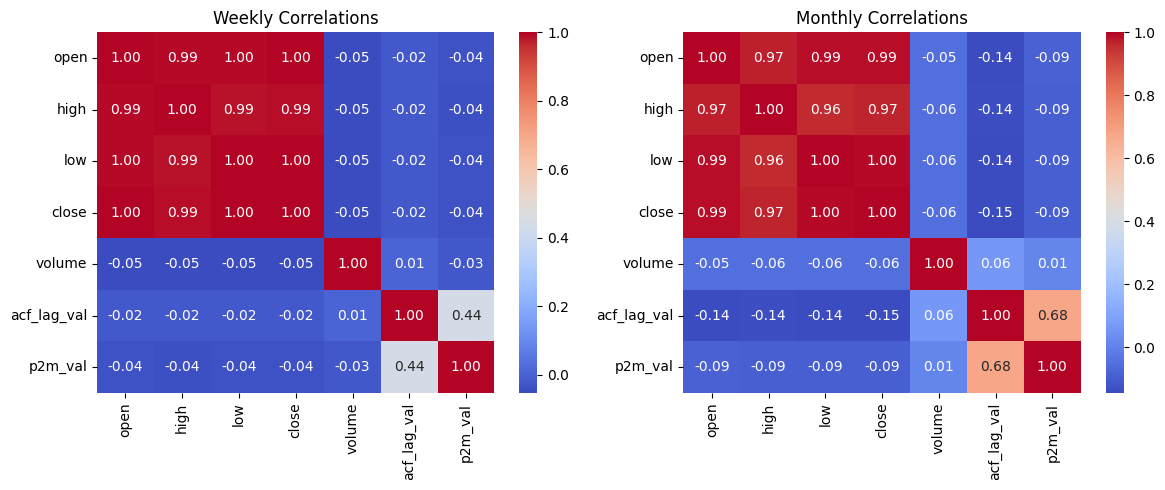

In [22]:
numeric_cols = ["open", "high", "low", "close", "volume", "acf_lag_val", "p2m_val"]

corr_w = df_w[numeric_cols].corr()
corr_m = df_m[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(corr_w, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Weekly Correlations")

sns.heatmap(corr_m, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Monthly Correlations")

plt.tight_layout()
plt.show()

**ACF Lag (```acf_lag_val```)**
- Weekly: correlations with OHLCV are around −0.02, effectively zero.
- Monthly: correlations are slightly more negative (around −0.14), but still weak.
- *Interpretation:*
    - The seasonality captured by ```acf_lag_val``` is not driven by absolute price levels or volume.
    - This is a good sign: the metric measures seasonality strength, independent of scale.

**P2M Val (```p2m_val```)**
- Weekly: also near-zero correlations with OHLCV (−0.04).
- Monthly: remains very low (−0.09).
- *Interpretation:*
    - Confirms P2M is orthogonal to price levels.
    - The only meaningful correlation is with ACF Lag (0.44 for W, 0.68 for M), meaning P2M partially overlaps with ACF but adds little new signal.


**Keys**
- Both seasonality metrics (```acf_lag_val```, ```p2m_val```) are independent of OHLCV values.
- Their predictive value (for future seasonality) will not be confounded by simple price/volume movements.
- The strong correlation between ACF and P2M (especially in monthly) suggests P2M reinforces what ACF detects, rather than providing a new angle.